# Laboratorio 6 - ¿Puede una red neuronal aprender a sumar?
## Calculadora neuronal con seq2seq y atención

**Universidad del Valle · Deep Learning 2026 · Kevin Recinos**

**Modalidad:** individual  
**Trabajo en clase:** viernes 2 y lunes 5 de octubre  
**Entrega:** jueves 8 de octubre de 2026, 23:59  
**Archivo:** este notebook ejecutado (su calculadora se registra sola al final)  
**Valor:** este laboratorio cuenta como **dos laboratorios**: el notebook es el Laboratorio 6 (100 puntos) y
el torneo es el Laboratorio 7

Una red recibe el texto `"4821+3976"` y debe escribir `"8797"`, carácter por carácter. Nadie le explica
qué es sumar ni qué es "llevar uno": solo ve ejemplos. Usted va a construir la pieza que le permite  
**mirar la parte correcta del problema** en cada paso -la atención de Bahdanau- y luego va a comprobar,
con un mapa de atención, si la red descubrió la suma por columnas que usted aprendió en la escuela.

El viernes 9 de octubre, en clase, su calculadora participa en el **Torneo de calculadoras neuronales**:
el profesor dice una clave, su notebook resuelve los problemas secretos y registra sus respuestas solo.  
**Su nota del Laboratorio 7** es su puntaje en el torneo dividido entre el mejor puntaje de la clase, por 100: **la mejor calculadora obtiene 100**, y nadie que envíe su calculadora baja de **60**. Vale 4 puntos de la nota final.

### Cómo se trabaja

| Bloque | Qué va a hacer | Tiempo | Puntos |
|:--|:--|:--:|--:|
| 0 | **Investigar.** Dos lecturas y tres preguntas | 30 min | 15 |
| 1 | **Ejecutar y observar.** El generador de problemas | 10 min | 5 |
| 2 | **Programar.** El módulo de atención aditiva | 25 min | 20 |
| 3 | **Programar.** Un paso del decoder con atención | 15 min | 15 |
| 4 | **Entrenar.** Calculadora con y sin atención | 15 min | 10 |
| 5 | **Analizar.** Exactitud por cifras y mapa de atención | 25 min | 15 |
| 6 | **Investigar con evidencia.** Su calculadora para el torneo | 40 min | 10 |
| 7 | **Romper su propia calculadora** y cerrar | 20 min | 10 |

Las celdas con `assert` son su verificación: si imprimen `OK`, el bloque está bien. Si fallan, corrija
antes de avanzar. **Solo programa en los Bloques 2 y 3**; el resto del código ya está escrito y usted lo
ejecuta, lo modifica a través de `CONFIG` y lo interpreta.

### Reglas

- Use PyTorch, matplotlib y la biblioteca estándar de Python. No use NumPy.
- No use `nn.MultiheadAttention` ni otra implementación de atención: la del Bloque 2 es suya.
- No modifique las celdas de verificación.
- La calculadora jamás puede calcular la respuesta con Python (`eval`, `int(a) + int(b)`, etc.): la
  respuesta sale del modelo, carácter por carácter.
- Respuestas escritas con sus propias palabras. Una IA no se considera fuente académica.
- Entregue el notebook ejecutado de arriba abajo, con todas las salidas visibles.


<style>
:root { --blue:#0066ff; --cyan:#00ffff; --ink:#1e1e1e; --paper:#ffffff; }
.jp-RenderedHTMLCommon h1, .jp-RenderedHTMLCommon h2, .jp-RenderedHTMLCommon h3 {
  color: var(--blue); font-family: "DejaVu Sans", sans-serif; font-weight: 700;
}
.jp-RenderedHTMLCommon h1 { border-bottom: 4px solid var(--cyan); padding-bottom: .35rem; }
.jp-RenderedHTMLCommon blockquote { border-left: 5px solid var(--cyan); background: #eef6ff; padding: .8rem 1rem; }
.jp-RenderedHTMLCommon table { border-collapse: collapse; }
.jp-RenderedHTMLCommon th { background: var(--ink); color: var(--paper); }
.jp-RenderedHTMLCommon code { color: #004bbd; }
.lab-card { border: 1px solid #bfd7ff; border-left: 6px solid var(--blue); border-radius: 8px;
  padding: 1rem 1.2rem; background: linear-gradient(135deg,#f7fbff,#ffffff); margin: 1rem 0; }
.lab-kicker { color:#0056d6; font-size:.82rem; font-weight:700; letter-spacing:.12em; text-transform:uppercase; }
</style>
<div class="lab-card"><div class="lab-kicker">Deep Learning · Laboratorio 6</div>
<strong>Bitácora reproducible:</strong> cada conclusión se apoya en las salidas visibles del notebook y en
artefactos versionados del experimento.</div>


In [1]:
# Identificación individual solicitada por la guía.
NOMBRE = "Pablo Daniel Barillas Moreno"
CARNE = "22193"

assert CARNE != "00000" and NOMBRE != "Escriba aquí su nombre", "Complete NOMBRE y CARNE."
print("OK -", NOMBRE, CARNE)

OK - Pablo Daniel Barillas Moreno 22193


In [2]:
import hashlib
import json
import random
import time
from pathlib import Path
from urllib.parse import parse_qs, urlencode, urlparse
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence

SEMILLA = 2026
DISPOSITIVO = torch.device("cpu")  # el modelo es pequeño: en CPU entrena en 1-3 minutos
CARPETA_MODELOS = Path("modelos_lab6")
CARPETA_MODELOS.mkdir(exist_ok=True)

# Formulario del curso donde se registra su calculadora. Lo configura el profesor: no lo cambie.
FORMULARIO = "https://docs.google.com/forms/d/e/1FAIpQLScMnEK5G8RncUK09wLMJly1rNUmyMADWZ1Kk2KhuVKX8HEGew/viewform?usp=pp_url&entry.602518229=x"


def enviar_registro(datos):
    """Envía un registro JSON al formulario del curso. Si falla, muestra el texto para pegarlo a mano."""
    texto = json.dumps(datos, ensure_ascii=False)
    try:
        partes = urlparse(FORMULARIO)
        campo = next(k for k in parse_qs(partes.query) if k.startswith("entry."))
        destino = f"{partes.scheme}://{partes.netloc}{partes.path.replace('viewform', 'formResponse')}"
        cuerpo = urlencode({campo: texto}).encode()
        with urlopen(Request(destino, data=cuerpo), timeout=20) as respuesta:
            assert respuesta.status == 200
        print("OK - registro enviado al formulario del curso")
        return True
    except Exception as error:
        print(f"No se pudo enviar el registro ({type(error).__name__}).")
        print("Abra el formulario del curso y pegue este texto completo en la única pregunta:\n")
        print(texto)
        return False


print("PyTorch", torch.__version__)

# Sistema visual Tech Innovation: consistente en todas las figuras del laboratorio.
AZUL_ELECTRICO, CIAN_NEON, GRIS_OSCURO = "#0066ff", "#00ffff", "#1e1e1e"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#f7fbff", "axes.edgecolor": GRIS_OSCURO,
    "axes.titleweight": "bold", "axes.titlecolor": AZUL_ELECTRICO,
    "axes.labelcolor": GRIS_OSCURO, "axes.prop_cycle": plt.cycler(color=[AZUL_ELECTRICO, "#00a6a6", "#7048e8"]),
    "grid.color": "#d8e8ff", "grid.alpha": 0.65, "font.family": "DejaVu Sans",
})


PyTorch 2.13.0+cpu


---
## Bloque 0 - Investigación guiada (15 puntos)

Antes de escribir código, lea estas dos secciones. Son cortas.

- **Bahdanau, Cho y Bengio (2014).** *Neural Machine Translation by Jointly Learning to Align and
  Translate.* Sección 3.1 y figura 3. <https://arxiv.org/abs/1409.0473>
- **Sutskever, Vinyals y Le (2014).** *Sequence to Sequence Learning with Neural Networks.* Sección 3.3,
  *Reversing the Source Sentences*. <https://arxiv.org/abs/1409.3215>

Responda en 3 a 6 líneas cada una, con lenguaje propio, y cite la sección utilizada.

1. Según Bahdanau, ¿qué problema aparece cuando el encoder debe comprimir toda la entrada en **un solo
   vector de tamaño fijo**? ¿Cómo lo resuelve el vector de contexto $c_i$, que cambia en cada paso de
   salida?
2. En el artículo, el puntaje $e_{ij} = a(s_{i-1}, h_j)$ compara el estado del decoder con cada estado del
   encoder. Explique qué serían $s_{i-1}$ y $h_j$ cuando la red está escribiendo el **tercer** dígito de la
   respuesta de `4821+3976`. ¿Qué pieza del Transformer del Lab 5 cumple el papel de $s_{i-1}$ y cuál el de
   $h_j$?
3. ¿Por qué invertir la oración de entrada mejoró los resultados de Sutskever? Ahora piense en cómo suma
   usted a mano: ¿empieza por la izquierda o por la derecha? **Antes de entrenar nada**, prediga: ¿ayudará
   a la calculadora invertir la entrada, la salida o ambas? Justifique su predicción.

### Respuestas

**1.** Un encoder que comprime toda la secuencia en un único vector de tamaño fijo crea un cuello de
botella: conforme crece la entrada, ese vector debe conservar demasiada información y puede perder
detalles relevantes. Bahdanau propone que, en cada paso de salida, el decoder construya un contexto
$c_i$ como suma ponderada de todos los estados del encoder; así consulta de forma selectiva la parte útil
de la entrada en vez de depender de un solo resumen.  
**Fuente:** Bahdanau, Cho y Bengio (2014), sección 3.1 y figura 3.

**2.** Al escribir el tercer dígito, $s_{i-1}$ es el estado del decoder después de haber producido los dos
dígitos anteriores; resume el prefijo ya escrito y la información acumulada. Cada $h_j$ representa un
carácter concreto de `4821+3976` después de ser procesado por el encoder. En el Transformer, el vector
de consulta (*query*) del decoder desempeña el papel de $s_{i-1}$ y las claves/valores derivados de la
salida del encoder corresponden a los $h_j$.  
**Fuente:** Bahdanau, Cho y Bengio (2014), sección 3.1.

**3.** Sutskever et al. invirtieron la fuente para reducir la distancia mínima entre elementos relacionados
de entrada y salida, facilitando la optimización sin cambiar la longitud promedio de las dependencias.
Como la suma manual comienza por unidades y propaga acarreos hacia la izquierda, predigo que invertir
la **salida** será especialmente útil: el decoder generará primero unidades y podrá transportar el acarreo
en su estado recurrente. Mantendré la entrada original para aislar una sola modificación.  
**Fuente:** Sutskever, Vinyals y Le (2014), sección 3.3.


---
## Bloque 1 - El generador de problemas (5 puntos)

No hay archivo de datos: cada problema se genera al azar. Los dos números tienen entre 1 y 4 cifras, la
operación es `+` o `-`, y en las restas el resultado nunca es negativo. Cada carácter es un *token*: el
vocabulario completo tiene 15 símbolos.

Ejecute la celda y observe los ejemplos.

      42-1 -> 41     tokens: [7, 5, 14, 4]
 7219+4439 -> 11658  tokens: [10, 5, 4, 12, 13, 7, 7, 6, 12]
    7386+6 -> 7392   tokens: [10, 6, 11, 9, 13, 9]
  4748+705 -> 5453   tokens: [7, 10, 7, 11, 13, 10, 3, 8]
     122+0 -> 122    tokens: [4, 5, 5, 13, 3]
   7915+13 -> 7928   tokens: [10, 12, 4, 8, 13, 4, 6]
 4818+6663 -> 11481  tokens: [7, 11, 4, 11, 13, 9, 9, 9, 6]
   1352-47 -> 1305   tokens: [4, 6, 8, 5, 14, 7, 10]


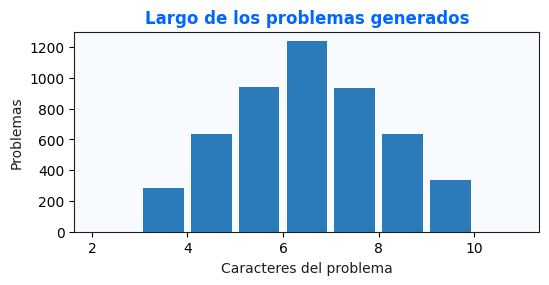

OK - generador y vocabulario listos


In [3]:
ESPECIALES = ["<PAD>", "<SOS>", "<EOS>"]
SIMBOLOS = list("0123456789+-")
TOKENS = ESPECIALES + SIMBOLOS
TOKEN_A_ID = {token: i for i, token in enumerate(TOKENS)}
PAD, SOS, EOS = 0, 1, 2
MAX_CIFRAS = 4  # regla del torneo: nadie entrena con números de más de 4 cifras


def generar_problema(rng, max_cifras=MAX_CIFRAS, min_cifras=1):
    """Devuelve (problema, respuesta) como texto, por ejemplo ("4821+3976", "8797")."""
    cifras_a = rng.randint(min_cifras, max_cifras)
    cifras_b = rng.randint(1, max_cifras)
    a = rng.randint(0 if cifras_a == 1 else 10 ** (cifras_a - 1), 10 ** cifras_a - 1)
    b = rng.randint(0 if cifras_b == 1 else 10 ** (cifras_b - 1), 10 ** cifras_b - 1)
    operacion = rng.choice("+-")
    if operacion == "-" and a < b:
        a, b = b, a
    respuesta = a + b if operacion == "+" else a - b
    return f"{a}{operacion}{b}", str(respuesta)


def generar_datos(n, semilla, max_cifras=MAX_CIFRAS):
    rng = random.Random(semilla)
    return [generar_problema(rng, max_cifras) for _ in range(n)]


def codificar(texto, inicio_fin):
    ids = [TOKEN_A_ID[c] for c in texto]
    return [SOS] + ids + [EOS] if inicio_fin else ids


ejemplos = generar_datos(8, semilla=1)
for problema, respuesta in ejemplos:
    print(f"{problema:>10} -> {respuesta:<6} tokens: {codificar(problema, False)}")

validacion = generar_datos(2000, semilla=SEMILLA + 1)
largos = [len(p) for p, _ in generar_datos(5000, semilla=3)]
plt.figure(figsize=(6, 2.6))
plt.hist(largos, bins=range(2, 12), rwidth=0.85, color="#2b7bba")
plt.xlabel("Caracteres del problema")
plt.ylabel("Problemas")
plt.title("Largo de los problemas generados")
plt.show()

assert len(TOKENS) == 15 and codificar("12+3", True) == [SOS, 4, 5, 13, 6, EOS]
print("OK - generador y vocabulario listos")

**Respuesta 1.1.** Cada operando de exactamente cuatro cifras admite 9,000 valores.
Para la suma existen $9{,}000^2=81{,}000{,}000$ pares ordenados. En la resta no negativa se permiten
$9{,}000(9{,}000+1)/2=40{,}504{,}500$ pares con $a\ge b$. En total hay **121,504,500** problemas,
muy por encima de los 40,000 ejemplos de entrenamiento (menos de 0.033 % del espacio, incluso antes de
considerar longitudes menores). Por tanto, el modelo no puede memorizar todas las respuestas posibles:
para generalizar debe aprender regularidades sobre dígitos, posiciones, acarreos y préstamos.


---
## Bloque 2 - La atención aditiva de Bahdanau (20 puntos)

El encoder lee el problema y deja un vector $h_j$ por cada carácter. Cada vez que el decoder va a escribir
un dígito, tiene un estado $s$ que resume lo que lleva escrito. La atención responde: **¿qué caracteres del
problema necesito mirar ahora?**

Se hace en tres pasos pequeños:

**Paso 1 - puntaje.** Una pequeña red compara el estado del decoder con cada carácter:

$$e_j = v^\top \tanh\left(W_q\, s + W_k\, h_j\right)$$

**Paso 2 - pesos.** Los puntajes se convierten en porcentajes que suman 1. Los `<PAD>` reciben puntaje
$-\infty$ para que su peso sea exactamente 0:

$$\alpha_j = \frac{e^{e_j}}{\sum_k e^{e_k}}$$

**Paso 3 - contexto.** El contexto es el promedio de los $h_j$, ponderado por los pesos:

$$c = \sum_j \alpha_j\, h_j$$

Las capas $W_q$, $W_k$ y $v$ ya están creadas. Usted escribe el `forward`. Formas de los tensores
(B = tamaño del lote, T = caracteres del problema):

| Tensor | Forma | Significado |
|:--|:--|:--|
| `estado_dec` | (B, dim_dec) | estado $s$ del decoder |
| `salidas_enc` | (B, T, dim_enc) | un $h_j$ por carácter |
| `mascara_pad` | (B, T) | `True` donde hay `<PAD>` |
| `contexto` (salida) | (B, dim_enc) | vector $c$ |
| `pesos` (salida) | (B, T) | los $\alpha_j$, suman 1 por fila |

In [4]:
class AtencionAditiva(nn.Module):
    def __init__(self, dim_dec, dim_enc, dim_att):
        super().__init__()
        self.W_q = nn.Linear(dim_dec, dim_att, bias=False)
        self.W_k = nn.Linear(dim_enc, dim_att, bias=False)
        self.v = nn.Linear(dim_att, 1, bias=False)

    def forward(self, estado_dec, salidas_enc, mascara_pad):
        # e_j = v^T tanh(W_q s + W_k h_j), calculado para todas las posiciones T.
        puntajes = self.v(torch.tanh(
            self.W_q(estado_dec).unsqueeze(1) + self.W_k(salidas_enc)
        )).squeeze(-1)
        puntajes = puntajes.masked_fill(mascara_pad, float("-inf"))
        pesos = torch.softmax(puntajes, dim=-1)
        contexto = torch.bmm(pesos.unsqueeze(1), salidas_enc).squeeze(1)
        return contexto, pesos

In [5]:
# Verificación con pesos fijos: todos deben obtener exactamente los mismos números.
torch.manual_seed(0)
att_prueba = AtencionAditiva(dim_dec=6, dim_enc=8, dim_att=5)
s_prueba = torch.randn(2, 6)
h_prueba = torch.randn(2, 4, 8)
mascara_prueba = torch.tensor([[False, False, False, False],
                               [False, False, True, True]])  # el 2.º problema es más corto

with torch.no_grad():
    contexto_b2, pesos_b2 = att_prueba(s_prueba, h_prueba, mascara_prueba)

assert contexto_b2 is not None and pesos_b2 is not None, "Complete el forward."
assert pesos_b2.shape == (2, 4) and contexto_b2.shape == (2, 8)
assert torch.allclose(pesos_b2.sum(-1), torch.ones(2)), "Los pesos deben sumar 1 por fila."
assert torch.all(pesos_b2[1, 2:] == 0), "Los <PAD> deben recibir peso exactamente 0."
print("pesos:\n", pesos_b2.round(decimals=4))
print("OK - atención aditiva correcta")

pesos:
 tensor([[0.3175, 0.1590, 0.2044, 0.3191],
        [0.5266, 0.4734, 0.0000, 0.0000]])
OK - atención aditiva correcta


---
## Bloque 3 - Un paso del decoder con atención (15 puntos)

El decoder escribe la respuesta un carácter a la vez. En cada paso:

1. Convierte el token anterior en un embedding (al inicio, el token anterior es `<SOS>`).
2. Le pregunta a la atención qué mirar, usando su estado **actual** (todavía no actualizado): obtiene
   `contexto` y `pesos`.
3. Actualiza su estado con la `GRUCell`, que recibe **[embedding, contexto]** concatenados en ese orden.
4. Calcula los logits del siguiente carácter con la capa `salida`, que recibe **[nuevo_estado, contexto]**
   concatenados en ese orden.

El encoder ya está escrito. Fíjese en `pack_padded_sequence`: le indica a la GRU dónde termina cada
problema para que nunca lea los `<PAD>`. Sin eso, el modelo aprende a depender del relleno y falla cuando
el lote no lo trae.

In [6]:
class Encoder(nn.Module):
    """GRU bidireccional: un vector por carácter y un resumen de todo el problema."""

    def __init__(self, n_tokens, dim_emb, dim_oculta):
        super().__init__()
        self.embedding = nn.Embedding(n_tokens, dim_emb, padding_idx=PAD)
        self.gru = nn.GRU(dim_emb, dim_oculta, batch_first=True, bidirectional=True)
        self.puente = nn.Linear(2 * dim_oculta, 2 * dim_oculta)

    def forward(self, src):
        largos = src.ne(PAD).sum(1).cpu()
        empaquetado = pack_padded_sequence(self.embedding(src), largos,
                                           batch_first=True, enforce_sorted=False)
        salidas, h_n = self.gru(empaquetado)
        salidas, _ = pad_packed_sequence(salidas, batch_first=True, total_length=src.size(1))
        resumen = torch.cat([h_n[0], h_n[1]], dim=-1)       # (B, 2*dim_oculta)
        estado_inicial = torch.tanh(self.puente(resumen))   # estado inicial del decoder
        return salidas, estado_inicial, resumen

In [7]:
class Decoder(nn.Module):
    def __init__(self, n_tokens, dim_emb, dim_dec, dim_enc, dim_att, usar_atencion=True):
        super().__init__()
        self.usar_atencion = usar_atencion
        self.embedding = nn.Embedding(n_tokens, dim_emb, padding_idx=PAD)
        self.atencion = AtencionAditiva(dim_dec, dim_enc, dim_att)
        self.gru = nn.GRUCell(dim_emb + dim_enc, dim_dec)
        self.salida = nn.Linear(dim_dec + dim_enc, n_tokens)

    def paso(self, token_previo, estado, salidas_enc, mascara_pad, resumen):
        """token_previo (B,), estado (B, dim_dec) -> logits, nuevo_estado, pesos."""
        if not self.usar_atencion:
            contexto, pesos = resumen, None
            emb = self.embedding(token_previo)
            nuevo_estado = self.gru(torch.cat([emb, contexto], dim=-1), estado)
            return self.salida(torch.cat([nuevo_estado, contexto], dim=-1)), nuevo_estado, pesos

        emb = self.embedding(token_previo)
        contexto, pesos = self.atencion(estado, salidas_enc, mascara_pad)
        nuevo_estado = self.gru(torch.cat([emb, contexto], dim=-1), estado)
        logits = self.salida(torch.cat([nuevo_estado, contexto], dim=-1))
        return logits, nuevo_estado, pesos

In [8]:
# Verificación con pesos fijos.
torch.manual_seed(1)
dec_prueba = Decoder(n_tokens=15, dim_emb=4, dim_dec=6, dim_enc=8, dim_att=5)
token_prueba = torch.tensor([SOS, 7])
with torch.no_grad():
    logits_b3, estado_b3, pesos_b3 = dec_prueba.paso(
        token_prueba, s_prueba, h_prueba, mascara_prueba, resumen=None
    )

assert logits_b3 is not None, "Complete el método paso."
assert logits_b3.shape == (2, 15) and estado_b3.shape == (2, 6) and pesos_b3.shape == (2, 4)
assert torch.all(pesos_b3[1, 2:] == 0)
print("logits del primer problema:", logits_b3[0].round(decimals=3))
print("OK - paso del decoder correcto")

logits del primer problema: tensor([-0.0290,  0.0560, -0.5270,  0.3400,  0.2520,  0.0540, -0.1340, -0.0500,
        -0.3540,  0.3590,  0.0860, -0.2820, -0.4980,  0.3680, -0.1880])
OK - paso del decoder correcto


---
## Bloque 4 - Entrenar la calculadora (10 puntos)

La clase `Calculadora` une encoder y decoder. Todo lo que se puede cambiar está en un diccionario
`CONFIG`; así su calculadora del torneo se puede reconstruir el día del torneo a partir de ese diccionario.

- `invertir_entrada` / `invertir_salida`: la red lee o escribe los caracteres al revés. La conversión se
  deshace automáticamente al leer la respuesta.
- `entrenar(...)` usa *teacher forcing*, igual que en el Lab 5, y guarda el modelo en `modelos_lab6/`. Si
  vuelve a ejecutar la celda con la misma configuración, **carga** el modelo guardado en lugar de
  entrenarlo otra vez.

Ejecute las dos celdas siguientes. Cada entrenamiento toma entre 1 y 3 minutos en CPU.

In [9]:
CONFIG_BASE = {
    "usar_atencion": True,
    "invertir_entrada": False,
    "invertir_salida": False,
    "dim_emb": 32,
    "dim_oculta": 64,
    "n_ejemplos": 40_000,
    "epocas": 15,
    "lr": 3e-3,
    "tamano_lote": 128,
    "semilla": SEMILLA,
}
MAX_PARAMETROS = 750_000  # regla del torneo


def preparar(texto, invertir):
    return texto[::-1] if invertir else texto


class Calculadora(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = dict(config)
        h = config["dim_oculta"]
        self.encoder = Encoder(len(TOKENS), config["dim_emb"], h)
        self.decoder = Decoder(len(TOKENS), config["dim_emb"], 2 * h, 2 * h, h,
                               usar_atencion=config["usar_atencion"])

    def forward(self, src, tgt_entrada):
        salidas_enc, estado, resumen = self.encoder(src)
        mascara = src.eq(PAD)
        logits = []
        for t in range(tgt_entrada.size(1)):  # teacher forcing: entra el carácter correcto
            logits_t, estado, _ = self.decoder.paso(tgt_entrada[:, t], estado, salidas_enc,
                                                    mascara, resumen)
            logits.append(logits_t)
        return torch.stack(logits, dim=1)

    @torch.no_grad()
    def resolver(self, problemas, max_largo=8, devolver_pesos=False):
        """Recibe textos como "4821+3976" y devuelve las respuestas escritas por la red."""
        self.eval()
        src = pad_sequence(
            [torch.tensor(codificar(preparar(p, self.config["invertir_entrada"]), False))
             for p in problemas], batch_first=True, padding_value=PAD)
        salidas_enc, estado, resumen = self.encoder(src)
        mascara = src.eq(PAD)
        token = torch.full((len(problemas),), SOS)
        escritos, pesos_todos = [], []
        for _ in range(max_largo):
            logits, estado, pesos = self.decoder.paso(token, estado, salidas_enc, mascara, resumen)
            token = logits.argmax(-1)
            escritos.append(token)
            pesos_todos.append(pesos)
        escritos = torch.stack(escritos, dim=1).tolist()
        respuestas = []
        for fila in escritos:
            fila = fila[:fila.index(EOS)] if EOS in fila else fila
            texto = "".join(TOKENS[i] for i in fila if i >= len(ESPECIALES))
            respuestas.append(preparar(texto, self.config["invertir_salida"]))
        if devolver_pesos:
            return respuestas, pesos_todos
        return respuestas


def contar_parametros(modelo):
    return sum(p.numel() for p in modelo.parameters())


def exactitud(modelo, pares):
    pred = modelo.resolver([p for p, _ in pares])
    return sum(a == r for a, (_, r) in zip(pred, pares)) / len(pares)


def huella(modelo):
    """Identificador corto de los pesos: permite comprobar que el modelo del torneo es el entregado."""
    datos = "".join(repr(t.detach().cpu().flatten().tolist()) for t in modelo.state_dict().values())
    return hashlib.sha256(datos.encode()).hexdigest()[:12]


def respuesta_correcta(problema):
    """Solo para revisar resultados en las gráficas; la calculadora nunca la usa."""
    operacion = "+" if "+" in problema else "-"
    a, b = (int(x) for x in problema.split(operacion))
    return str(a + b if operacion == "+" else a - b)


def entrenar(config, nombre, reentrenar=False):
    ruta = CARPETA_MODELOS / f"{nombre}.pt"
    modelo = Calculadora(config).to(DISPOSITIVO)
    assert contar_parametros(modelo) <= MAX_PARAMETROS, "Supera el máximo de parámetros del torneo."
    if ruta.exists() and not reentrenar:
        guardado = torch.load(ruta, weights_only=True)
        if guardado["config"] == config:
            modelo.load_state_dict(guardado["estado"])
            print(f"[{nombre}] cargado desde {ruta} - exactitud validación {exactitud(modelo, validacion):.3f}")
            return modelo, guardado["historia"]

    rng = random.Random(config["semilla"])
    torch.manual_seed(config["semilla"])
    datos = generar_datos(config["n_ejemplos"], semilla=config["semilla"])
    srcs = [torch.tensor(codificar(preparar(p, config["invertir_entrada"]), False)) for p, _ in datos]
    tgts = [torch.tensor(codificar(preparar(r, config["invertir_salida"]), True)) for _, r in datos]
    optimizador = torch.optim.Adam(modelo.parameters(), lr=config["lr"])
    criterio = nn.CrossEntropyLoss(ignore_index=PAD)
    historia = {"perdida": [], "exactitud_val": []}
    inicio = time.time()

    for epoca in range(1, config["epocas"] + 1):
        modelo.train()
        orden = list(range(len(datos)))
        rng.shuffle(orden)
        total = 0.0
        for k in range(0, len(orden), config["tamano_lote"]):
            lote = orden[k:k + config["tamano_lote"]]
            src = pad_sequence([srcs[i] for i in lote], batch_first=True, padding_value=PAD)
            tgt = pad_sequence([tgts[i] for i in lote], batch_first=True, padding_value=PAD)
            logits = modelo(src, tgt[:, :-1])
            perdida = criterio(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))
            optimizador.zero_grad()
            perdida.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
            optimizador.step()
            total += perdida.item() * len(lote)
        historia["perdida"].append(total / len(datos))
        historia["exactitud_val"].append(exactitud(modelo, validacion[:500]))
        if epoca == 1 or epoca % 5 == 0 or epoca == config["epocas"]:
            print(f"[{nombre}] época {epoca:02d} | pérdida {historia['perdida'][-1]:.4f} | "
                  f"exactitud val {historia['exactitud_val'][-1]:.3f} | {time.time() - inicio:.0f} s")

    torch.save({"config": config, "estado": modelo.state_dict(), "historia": historia}, ruta)
    print(f"[{nombre}] exactitud validación completa: {exactitud(modelo, validacion):.3f}")
    return modelo, historia

[base_con_atencion] cargado desde modelos_lab6\base_con_atencion.pt - exactitud validación 0.837
[base_sin_atencion] cargado desde modelos_lab6\base_sin_atencion.pt - exactitud validación 0.672


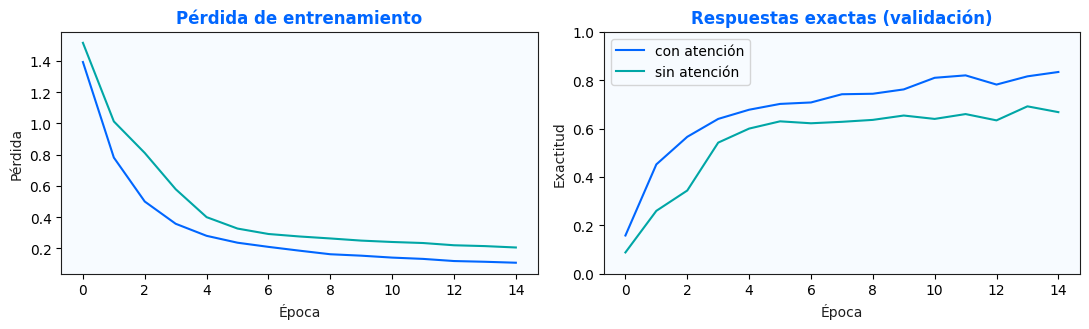

4821+3976 -> 12807
999+1 -> 1000
7305-2618 -> 4687


OK - calculadora entrenada. Exactitud con atención: 0.837, sin atención: 0.672


In [10]:
modelo_atencion, historia_atencion = entrenar(CONFIG_BASE, "base_con_atencion")
modelo_sin, historia_sin = entrenar({**CONFIG_BASE, "usar_atencion": False}, "base_sin_atencion")

fig, ejes = plt.subplots(1, 2, figsize=(11, 3.4))
for historia, etiqueta in [(historia_atencion, "con atención"), (historia_sin, "sin atención")]:
    ejes[0].plot(historia["perdida"], label=etiqueta)
    ejes[1].plot(historia["exactitud_val"], label=etiqueta)
ejes[0].set(xlabel="Época", ylabel="Pérdida", title="Pérdida de entrenamiento")
ejes[1].set(xlabel="Época", ylabel="Exactitud", title="Respuestas exactas (validación)", ylim=(0, 1))
ejes[1].legend()
plt.tight_layout()
plt.show()

for problema in ["4821+3976", "999+1", "7305-2618"]:
    print(problema, "->", modelo_atencion.resolver([problema])[0])

exactitud_base = exactitud(modelo_atencion, validacion)
assert exactitud_base >= 0.60, "Revise los Bloques 2 y 3: la calculadora con atención no aprendió."
print(f"OK - calculadora entrenada. Exactitud con atención: {exactitud_base:.3f}, "
      f"sin atención: {exactitud(modelo_sin, validacion):.3f}")

---
## Bloque 5 - ¿Dónde ayuda la atención y qué está mirando? (15 puntos)

Dos herramientas, ya escritas:

1. **Exactitud por cifras.** Compara ambos modelos en problemas de 1 a 6 cifras. Las columnas 5 y 6 están
   **fuera** del rango de entrenamiento: nunca vio números tan largos.
2. **Mapa de atención.** Cada fila es un carácter que la red escribió; cada columna, un carácter del
   problema (en el orden en que la red lo leyó). Más oscuro = más peso.

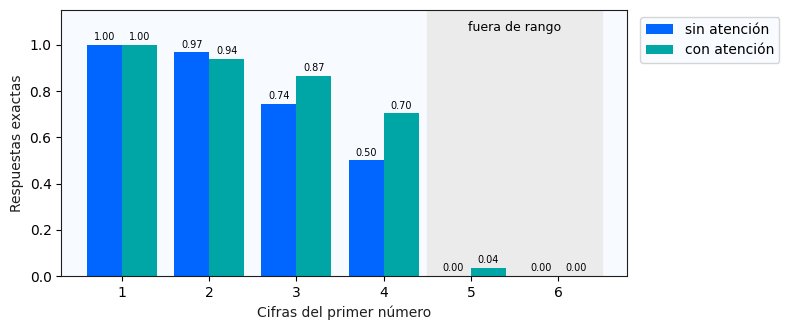

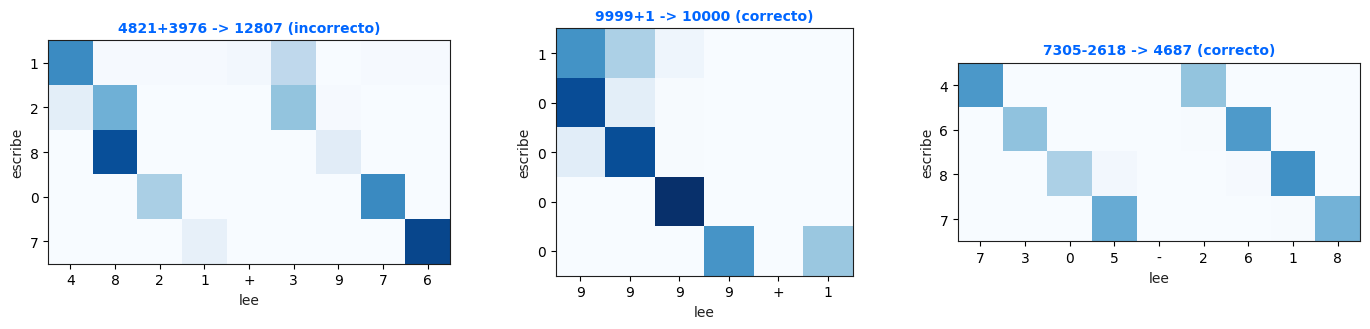

In [11]:
def exactitud_por_cifras(modelo, max_cifras=6, n=300):
    rng = random.Random(77)
    resultado = {}
    for cifras in range(1, max_cifras + 1):
        pares = [generar_problema(rng, max_cifras=cifras, min_cifras=cifras) for _ in range(n)]
        resultado[cifras] = exactitud(modelo, pares)
    return resultado


def graficar_por_cifras(modelos):
    plt.figure(figsize=(8, 3.4))
    ancho = 0.8 / len(modelos)
    for k, (etiqueta, modelo) in enumerate(modelos.items()):
        valores = exactitud_por_cifras(modelo)
        x = [c + (k - (len(modelos) - 1) / 2) * ancho for c in valores]
        barras = plt.bar(x, valores.values(), width=ancho, label=etiqueta)
        plt.bar_label(barras, fmt="%.2f", fontsize=7, padding=2)
    plt.axvspan(4.5, 6.5, color="0.92", zorder=0)
    plt.text(5.5, 1.06, "fuera de rango", ha="center", fontsize=9)
    plt.xlabel("Cifras del primer número")
    plt.ylabel("Respuestas exactas")
    plt.ylim(0, 1.15)
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    plt.show()


def mapa_atencion(modelo, problemas):
    if not modelo.config["usar_atencion"]:
        print("Este modelo no usa atención: no tiene mapa que mostrar.")
        return
    fig, ejes = plt.subplots(1, len(problemas), figsize=(4.6 * len(problemas), 3.4))
    for eje, problema in zip(ejes, problemas):
        respuesta, pesos = modelo.resolver([problema], devolver_pesos=True)
        leido = preparar(problema, modelo.config["invertir_entrada"])
        escrito = preparar(respuesta[0], modelo.config["invertir_salida"])
        matriz = torch.stack([p[0] for p in pesos[:len(escrito)]])
        eje.imshow(matriz, cmap="Blues", vmin=0, vmax=1)
        eje.set_xticks(range(len(leido)), list(leido))
        eje.set_yticks(range(len(escrito)), list(escrito))
        eje.set_xlabel("lee" + (" (invertido)" if modelo.config["invertir_entrada"] else ""))
        eje.set_ylabel("escribe" + (" (invertido)" if modelo.config["invertir_salida"] else ""))
        correcto = "correcto" if respuesta[0] == respuesta_correcta(problema) else "incorrecto"
        eje.set_title(f"{problema} -> {respuesta[0]} ({correcto})", fontsize=10)
    plt.tight_layout()
    plt.show()


graficar_por_cifras({"sin atención": modelo_sin, "con atención": modelo_atencion})
mapa_atencion(modelo_atencion, ["4821+3976", "9999+1", "7305-2618"])

**Pregunta 5.1.** La mayor ventaja observada de la atención apareció en **4 cifras**:
70.3% frente a 50.0%, una diferencia de +20.3%.
Con una o dos cifras la secuencia es corta y un resumen fijo todavía puede retener casi toda la información;
al crecer la entrada se intensifica el cuello de botella descrito en el Bloque 0. Fuera del rango de
entrenamiento (cinco y seis cifras), ambos modelos muestran además que la atención no garantiza por sí
sola extrapolación algorítmica.

**Pregunta 5.2.** En `4821+3976` el mapa no equivale a una regla simbólica rígida: distribuye peso entre
posiciones de ambos operandos, aunque concentra regiones distintas conforme avanza la salida. El baseline
debe escribir primero el dígito más significativo, pero ese dígito depende de acarreos originados a la
derecha; por eso necesita anticipar información que todavía no ha exteriorizado. La visualización se
interpreta como evidencia de alineación aprendida, no como prueba de que cada celda represente literalmente
una columna de la suma.


---
## Bloque 6 - Su calculadora para el torneo (10 puntos)

Ahora mejore la calculadora. Cambie **una o dos perillas** de `CONFIG` a partir de `CONFIG_BASE`, apoyado en
lo que investigó en el Bloque 0 y lo que vio en el Bloque 5. Algunas ideas, no una lista cerrada:

- invertir la entrada, la salida o ambas;
- más capacidad (`dim_oculta`), más ejemplos o más épocas;
- otra tasa de aprendizaje;
- modificar `generar_problema` para mostrar más casos difíciles (por ejemplo, acarreos en cadena), siempre
  con números de **máximo 4 cifras**.

**Reglas del torneo para este bloque.** No cambie la arquitectura: modifique solo `CONFIG` (y, si quiere,
el generador de datos, siempre con números de máximo 4 cifras). Máximo 750,000 parámetros. El tiempo de
entrenamiento es libre, pero tenga en cuenta su propio tiempo. La calculadora que entrene aquí es la que
compite en el torneo.

Antes de entrenar, complete la hipótesis:

**Hipótesis.** Creo que cambiar únicamente `invertir_salida=True` mejorará la exactitud en
problemas de cuatro cifras y con acarreos o préstamos encadenados, porque el decoder producirá primero
las unidades y podrá transportar esa información hacia las posiciones siguientes en su estado recurrente.
Lo consideraré útil si supera al baseline con atención en cuatro cifras y mantiene o mejora la exactitud
global de validación, sin aumentar parámetros, datos ni épocas.


[torneo_22193] cargado desde modelos_lab6\torneo_22193.pt - exactitud validación 0.972
Parámetros: 186767


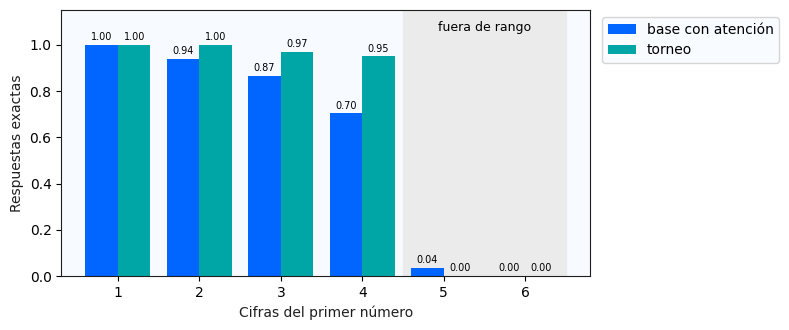

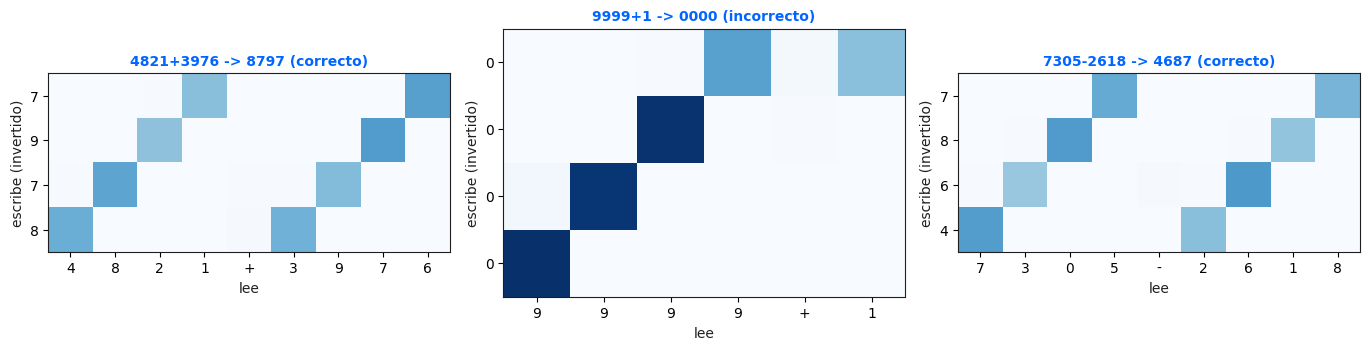

In [12]:
CONFIG_TORNEO = {
    **CONFIG_BASE,
    "invertir_salida": True,  # única perilla: generación desde unidades hacia la izquierda
}

modelo_torneo, historia_torneo = entrenar(CONFIG_TORNEO, f"torneo_{CARNE}")
print("Parámetros:", contar_parametros(modelo_torneo))

graficar_por_cifras({"base con atención": modelo_atencion, "torneo": modelo_torneo})
mapa_atencion(modelo_torneo, ["4821+3976", "9999+1", "7305-2618"])

**Resultado.** La hipótesis **se cumplió**. Al invertir solo la salida, la exactitud de cuatro
cifras cambió de 70.3% a 95.0% y la validación global de 83.7% a 97.2%.
El mapa del modelo de torneo debe leerse en el orden de generación invertido: primero resuelve posiciones
de menor valor y luego avanza hacia la izquierda, una secuencia compatible con la propagación de acarreo.
La comparación está controlada porque conserva arquitectura, semilla, datos, épocas y capacidad; su
limitación es que utiliza una sola semilla y 300 ejemplos por longitud, por lo que no estima variabilidad
entre entrenamientos ni cubre exhaustivamente el espacio de problemas.


---
## Bloque 7 - Rompa su propia calculadora (10 puntos)

Un buen ingeniero conoce los límites de su modelo antes de que otros los encuentren. Busque **5 problemas
que su calculadora del torneo resuelva mal**. Pruebe, observe y ajuste: los acarreos largos, los ceros y
las restas con resultado pequeño son buenos lugares para empezar.

Cada problema debe respetar las reglas del entrenamiento: dos números enteros de **máximo 4 cifras**, sin
ceros a la izquierda, `+` o `-`, y resultado no negativo. Problemas de 5 cifras no cuentan: ahí ya sabemos
que falla.

Al lado de cada uno, escriba en un comentario **por qué** cree que falla.

In [13]:
TRAMPAS = [
    "9999+1",  # acarreo que atraviesa todas las columnas
    "9998+2",  # acarreo encadenado desde las unidades
    "9999+9999",  # acarreos en las cuatro posiciones
    "1000-999",  # préstamo encadenado con resultado pequeño
    "4000-3999",  # préstamos a través de ceros internos
]


def es_trampa_valida(texto):
    for operacion in "+-":
        partes = texto.split(operacion)
        if len(partes) == 2 and all(p.isdigit() and len(p) <= MAX_CIFRAS for p in partes):
            a, b = partes
            if (len(a) > 1 and a[0] == "0") or (len(b) > 1 and b[0] == "0"):
                return False
            return operacion == "+" or int(a) >= int(b)
    return False


assert len(TRAMPAS) == 5 and all(es_trampa_valida(t) for t in TRAMPAS), "Escriba 5 problemas válidos."
assert len(set(TRAMPAS)) == 5, "Los 5 problemas deben ser distintos."
rotas = 0
for trampa, respuesta in zip(TRAMPAS, modelo_torneo.resolver(TRAMPAS)):
    falla = respuesta != respuesta_correcta(trampa)
    rotas += falla
    print(f"{trampa:>10} -> {respuesta:<7} {'FALLA' if falla else 'correcto: busque otro'}")
print(f"OK - {rotas} de 5 problemas rompen su calculadora")


    9999+1 -> 0000    FALLA
    9998+2 -> 0000    FALLA
 9999+9999 -> 18998   FALLA
  1000-999 -> 11      FALLA
 4000-3999 -> 001     FALLA
OK - 5 de 5 problemas rompen su calculadora


**Reflexión final.** `9999+1` es el caso que mejor expone la debilidad seleccionada: la red
produce `0000` cuando la respuesta correcta es `10000`. El mapa de atención permite comprobar
que el modelo sí consulta caracteres pertinentes, pero la alineación visual no asegura que ejecute de
forma consistente una regla de acarreo o préstamo. Concluyo que aprendió una aproximación estadística que
**imita muchas sumas y restas** dentro de la distribución, no un algoritmo simbólico infalible: cinco
contraejemplos válidos bastan para refutar una regla universal, aun cuando su exactitud promedio sea alta.


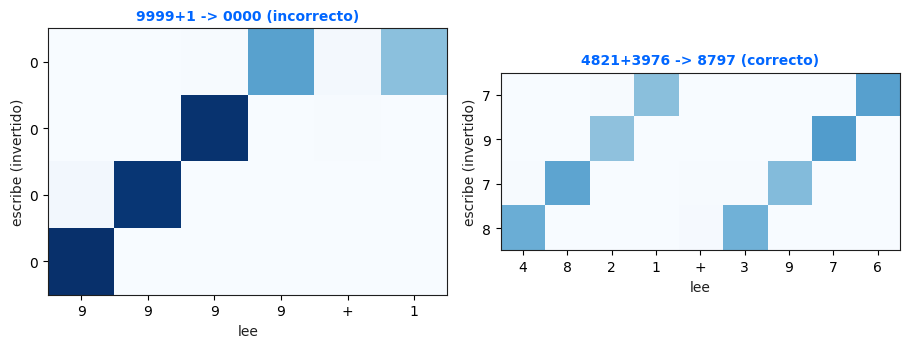

In [14]:
TRAMPA_ELEGIDA = TRAMPAS[0]  # cambie el índice si quiere analizar otro problema
mapa_atencion(modelo_torneo, [TRAMPA_ELEGIDA, "4821+3976"])

### Entrega

La celda siguiente **registra su calculadora** en el formulario del curso: envía su carné, la huella de su
modelo y los valores de verificación. Necesita conexión a internet. Si la ejecuta varias veces, cuenta el
último registro antes de la fecha límite.

Después, **suba a Canvas este notebook** ejecutado. Antes: reinicie el kernel, ejecute todo, confirme los
mensajes `OK` y guarde con las salidas visibles. Los modelos ya guardados en `modelos_lab6/` se cargan sin
volver a entrenar.

**No borre la carpeta `modelos_lab6/`:** la necesita el día del torneo. Si la pierde y vuelve a entrenar,
la huella cambia y su puntaje del torneo se reduce un 30 %.

In [ ]:
VALORES_ENTREGA = {
    "pesos_b2": pesos_b2.round(decimals=4).tolist(),
    "contexto_b2": contexto_b2.round(decimals=4).tolist(),
    "logits_b3": logits_b3.round(decimals=4).tolist(),
    "estado_b3": estado_b3.round(decimals=4).tolist(),
}
registro = {
    "momento": "entrega",
    "carne": CARNE,
    "nombre": NOMBRE,
    "huella": huella(modelo_torneo),
    "parametros": contar_parametros(modelo_torneo),
    "config": modelo_torneo.config,
    "exactitud_validacion": round(exactitud(modelo_torneo, validacion), 4),
    "trampas": TRAMPAS,
    "valores": VALORES_ENTREGA,
}
marca = CARPETA_MODELOS / "registro_enviado.txt"
if marca.exists() and marca.read_text() == registro["huella"]:
    print("Esta calculadora ya estaba registrada: no se envía de nuevo.")
elif enviar_registro(registro):
    marca.write_text(registro["huella"])
print("Huella de su calculadora:", registro["huella"])
print("Exactitud de validación:", registro["exactitud_validacion"])

---
## Torneo de calculadoras neuronales - viernes 9 de octubre

**No ejecute nada aquí antes del torneo.** En clase, el profesor dirá en voz alta una **clave**. Abra este
notebook, ejecute todo (los modelos se cargan de `modelos_lab6/`, no se reentrenan), escriba la clave y
ejecute la última celda. Su calculadora resuelve los problemas secretos y **sus respuestas se registran
solas**. El profesor recalcula todos los puntajes a partir de esas respuestas.

| Nivel | Qué contiene | Puntos |
|:--|:--|--:|
| 1 · Calentamiento | 20 problemas de 1 a 3 cifras | 15 |
| 2 · Cuatro cifras | 20 problemas con ambos números de 4 cifras | 30 |
| 3 · Acarreos en cadena | 16 problemas donde el acarreo o el préstamo recorre varias columnas | 40 |
| 4 · Jefe final | 10 problemas con un número de **5 cifras**, nunca vistos | 15 |

**Su nota del Laboratorio 7** es su puntaje en el torneo dividido entre el mejor puntaje de la clase, por 100: **la mejor calculadora obtiene 100**, y nadie que envíe su calculadora baja de **60**. Vale 4 puntos de la nota final. Cuenta el **primer** envío con la clave correcta. La huella debe ser la misma que registró al
entregar: si no coincide (por ejemplo, porque volvió a entrenar), su puntaje se reduce un 30 %. Empate en
el podio: va primero la calculadora con menos parámetros. Los tres primeros lugares vuelven a ejecutar la
celda frente a la clase.

In [ ]:
CLAVE = None  # el día del torneo: escriba aquí el número que diga el profesor, por ejemplo CLAVE = 1234


def cuatro_cifras(rng):
    a, b = rng.randint(1000, 9999), rng.randint(1000, 9999)
    operacion = rng.choice("+-")
    if operacion == "-" and a < b:
        a, b = b, a
    return f"{a}{operacion}{b}"


def acarreo_en_cadena(rng):
    """Sumas cuyas columnas suman 9 (el acarreo viaja de punta a punta) o restas desde un número redondo."""
    cifras = rng.randint(3, 4)
    if rng.random() < 0.5:
        a = [rng.randint(1 if i == 0 else 0, 9) for i in range(cifras)]
        b = [9 - x for x in a]
        b[-1] = min(9, b[-1] + 1)
        return f"{''.join(map(str, a))}+{''.join(map(str, b)).lstrip('0') or '0'}"
    a = rng.randint(1, 9) * 10 ** (cifras - 1)
    return f"{a}-{rng.randint(1, 99)}"


def cinco_cifras(rng):
    return f"{rng.randint(10000, 99999)}{rng.choice('+-')}{rng.randint(10, 9999)}"


def generar_torneo(clave):
    rng = random.Random(f"torneo-{clave}")
    return {
        "1 · Calentamiento": (15, [generar_problema(rng, max_cifras=3)[0] for _ in range(20)]),
        "2 · Cuatro cifras": (30, [cuatro_cifras(rng) for _ in range(20)]),
        "3 · Acarreos en cadena": (40, [acarreo_en_cadena(rng) for _ in range(16)]),
        "4 · Jefe final": (15, [cinco_cifras(rng) for _ in range(10)]),
    }


def calificar_torneo(niveles, respuestas):
    puntaje = {}
    for nivel, (puntos, problemas) in niveles.items():
        aciertos = sum(r == respuesta_correcta(p) for r, p in zip(respuestas[nivel], problemas))
        puntaje[nivel] = puntos * aciertos / len(problemas)
    return puntaje


if CLAVE is None:
    print("Torneo: espere la clave del viernes 9 de octubre.")
else:
    niveles = generar_torneo(CLAVE)
    respuestas_torneo = {nivel: modelo_torneo.resolver(problemas)
                         for nivel, (_, problemas) in niveles.items()}
    puntaje = calificar_torneo(niveles, respuestas_torneo)
    for nivel, puntos in puntaje.items():
        print(f"{nivel:24s} {puntos:5.1f} / {niveles[nivel][0]}")
    print(f"{'TOTAL':24s} {sum(puntaje.values()):5.1f} / 100")
    enviar_registro({
        "momento": "torneo",
        "carne": CARNE,
        "nombre": NOMBRE,
        "clave": CLAVE,
        "huella": huella(modelo_torneo),
        "parametros": contar_parametros(modelo_torneo),
        "respuestas": respuestas_torneo,
    })